In [22]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import pickle

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
with open("tokens.pkl", "rb") as f:
    data = pickle.load(f)

print(data["headlines_tokens"][:10])   
print(data["categories"][:5])          


['family', 'generation', 'changer', 'firestorm', 'aol', 'employee', 'benefit', 'cut', 'dakota', 'access']
['IMPACT', 'BUSINESS', 'POLITICS', 'GREEN', 'SCIENCE']


In [4]:
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['headlines_tokens', 'description_tokens', 'categories'])


## Bag of Word Implementation

In [5]:
docs = [
    " ".join(data["headlines_tokens"]),
    " ".join(data["description_tokens"])
]

In [6]:
type(data["headlines_tokens"])

list

In [7]:
vectorizer = CountVectorizer()
model_bow = vectorizer.fit_transform(docs)

In [8]:
from itertools import islice

print("Vocabulary:", dict(islice(vectorizer.vocabulary_.items(), 5)))
print("Feature Names:", vectorizer.get_feature_names_out()[:5])
print("Bag of Words Representation:\n", model_bow.toarray()[:5, :5])

Vocabulary: {'family': 6915, 'generation': 7867, 'changer': 3472, 'firestorm': 7216, 'aol': 1364}
Feature Names: ['0000' '002' '007' '01042013' '05152013']
Bag of Words Representation:
 [[0 1 1 0 0]
 [1 0 0 1 1]]


In [9]:
word_counts = np.sum(model_bow.toarray(), axis=0)
words = vectorizer.get_feature_names_out()
df = pd.DataFrame({"words": words, "frequency": word_counts, })

top10_df = df.sort_values(by="frequency", ascending=False).head(10)

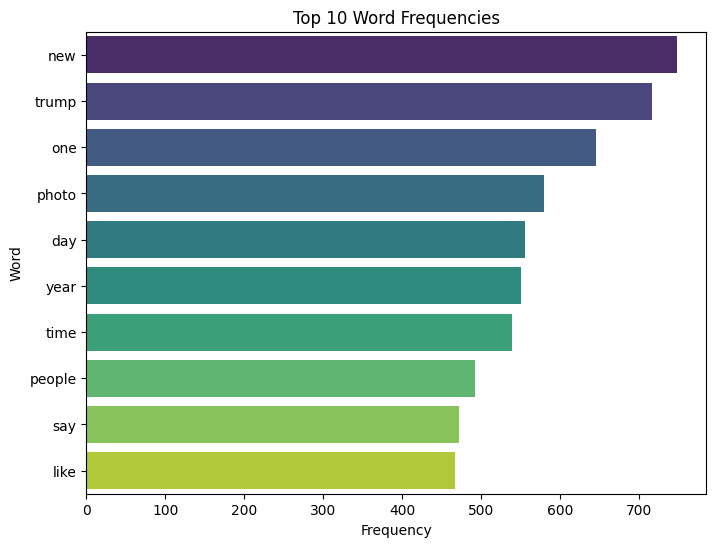

In [10]:
plt.figure(figsize=(8,6))
sns.barplot(x="frequency", y="words", data=top10_df, palette="viridis")

plt.title("Top 10 Word Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## Model Implementation

In [11]:
# join descriptions per each article
def combine(data):
    articles = []
    for headline_tokens, desc_tokens in zip(data["headlines_tokens"], data["description_tokens"]):

        headline = " ".join(headline_tokens.split())
        description = " ".join(desc_tokens.split())

        articles.append(headline + " " + description)
    return articles


In [12]:
articles = combine(data)
print(type(articles)) 

<class 'list'>


In [13]:
print(len(articles))                 
print(articles[0])          # combined document

54275
family wont


### Baseline Model

In [14]:
pipeline_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1,2), max_features=10000)),
    ('kmeans', KMeans(n_clusters=10, random_state=22))
])

In [15]:
pipeline_baseline.fit(articles)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [16]:
labels = pipeline_baseline.predict(articles[:20]) 
print (labels)

[2 2 4 2 2 2 2 2 2 4 2 2 2 2 2 2 2 2 2 2]


In [17]:
labels_baseline = pipeline_baseline.named_steps['kmeans'].labels_ 
X_tfidf = pipeline_baseline.named_steps['tfidf'].transform(articles)

In [20]:
svd = TruncatedSVD(n_components=300, random_state=22) 
X_reduced_tfidf = svd.fit_transform(X_tfidf)

In [24]:
print("Silhouette:", silhouette_score(X_reduced_tfidf, labels_baseline)) 
print("Calinski-Harabasz:", calinski_harabasz_score(X_reduced_tfidf, labels_baseline))
print("Davies–Bouldin Index:", davies_bouldin_score(X_reduced_tfidf, labels_baseline))

Silhouette: -0.3898021638745888
Calinski-Harabasz: 175.44950360927749
Davies–Bouldin Index: 3.7664591996983106


### BERTopic

In [34]:
from sentence_transformers import SentenceTransformer
import hdbscan

ModuleNotFoundError: No module named 'bertopic'

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
umap_model = umap.UMAP(n_neighbors=15, n_components=50)

topic_model = BERTopic(embedding_model=model, umap_model=umap_model)
topics, probs = topic_model.fit_transform(headlines)

In [26]:
pipeline_kmeans.fit(articles)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [27]:
labels = pipeline_kmeans.predict(articles[:20]) 
print (labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0]


In [35]:
print(set(pipeline_kmeans.predict(articles)))  # Which cluster IDs are present?

{np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)}


In [33]:
labels_pca = pipeline_kmeans.named_steps['kmeans'].labels_ 
X_pca = pipeline_kmeans.named_steps['tfidf'].transform(articles)

In [31]:
svd_2 = TruncatedSVD(n_components=300, random_state=22) 
X_reduced_tfidf_2 = svd_2.fit_transform(X_pca)

In [32]:
print("Silhouette_pca:", silhouette_score(X_reduced_tfidf_2, labels_baseline)) 
print("Calinski-Harabasz_pca:", calinski_harabasz_score(X_reduced_tfidf_2, pipeline_kmeans))
print("Davies–Bouldin Index_pca:", davies_bouldin_score(X_reduced_tfidf_2, pipeline_kmeans))

Silhouette_pca: 0.34881797736108977


ValueError: Found input variables with inconsistent numbers of samples: [54275, 3]

### Hyperparameter Tuning

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score

# Custom scorer for clustering
def silhouette_scorer(estimator, X):
    labels = estimator.named_steps['kmeans'].labels_
    return silhouette_score(X, labels)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words="english")),
    ('svd', TruncatedSVD(random_state=22)),
    ('kmeans', KMeans(random_state=22))
])

param_grid = {
    'tfidf__max_features': [2000, 5000, 10000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'svd__n_components': [100, 300, 500],
    'kmeans__n_clusters': [5, 10, 20]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=make_scorer(silhouette_scorer),
    cv=[(slice(None), slice(None))],  # unsupervised trick: use all data
    verbose=2
)

grid.fit(articles)

print("Best params:", grid.best_params_)
print("Best silhouette score:", grid.best_score_)
